# ***Проект "Прогнозирование температуры плавления стали"***

Чтобы оптимизировать производственные расходы, металлургический комбинат ООО «Так закаляем сталь» решил уменьшить потребление электроэнергии на этапе обработки стали. Вам предстоит построить модель, которая предскажет температуру стали.

***Описание этапа обработки***

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн. Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом. Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены в крышке ковша. 

Из сплава выводится сера (десульфурация), добавлением примесей корректируется химический состав и отбираются пробы. Сталь легируют — изменяют её состав — подавая куски сплава из бункера для сыпучих материалов или проволоку через специальный трайб-аппарат (англ. tribe, «масса»).

Перед тем как первый раз ввести легирующие добавки, измеряют температуру стали и производят её химический анализ. Потом температуру на несколько минут повышают, добавляют легирующие материалы и продувают сплав инертным газом. Затем его перемешивают и снова проводят измерения. Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.

Тогда расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки. Оттуда готовый продукт выходит в виде заготовок-слябов (англ. *slab*, «плита»).

***Описание данных***

Данные состоят из файлов, полученных из разных источников:

- `data_arc.csv` — данные об электродах;
- `data_bulk.csv` — данные о подаче сыпучих материалов (объём);
- `data_bulk_time.csv` *—* данные о подаче сыпучих материалов (время);
- `data_gas.csv` — данные о продувке сплава газом;
- `data_temp.csv` — результаты измерения температуры;
- `data_wire.csv` — данные о проволочных материалах (объём);
- `data_wire_time.csv` — данные о проволочных материалах (время).

Во всех файлах столбец `key` содержит номер партии. В файлах может быть несколько строк с одинаковым значением `key`: они соответствуют разным итерациям обработки.

***Критерии оценки проекта «Промышленность»***

Целевой признак: последняя измеренная температура.

Метрика: MAE

Критерии оценки

- MAE > 8.7 — 0 sp
- 7.6 < MAE ≤ 8.7 — 4 sp
- 6.8 < MAE ≤ 7.6 — 4.5 sp
- 6.3 < MAE ≤ 6.8 — 5 sp
- 6.0 < MAE ≤ 6.3 — 5.5 sp
- MAE ≤ 6.0 — 6 sp

***План работы***

    - Подготовить данные. Изменить типы данных; определить и использовать номера партий, у которых есть замеры по температуре.
    - Подготовка признаков. Составление единой таблицы со всеми данными для модели. Выделение целевого признака как последний замер в серии замеров. Разделение на features и target со смешиванием данных.
    - Выбор моделей. Использование и обучение регрессионных моделей, например, CatBoostRegressor, LGBMRegressor и т.д.
    - Оценка эффективности моделей на тестовой выборке.


In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from scipy import stats as st
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from pyod.models.knn import KNN
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

## Изучение данных

Напишем функцию для просмотра значений внутри столбцов

In [2]:
def show_rows(data_frame):
    for column in data_frame.columns:
        print('Уникальные значения столбца', column)
        print(data_frame[column].sort_values().unique())

### Данные об электродах

In [3]:
data_arc = pd.read_csv('/datasets/final_steel/data_arc.csv')

Посмотрим на таблицу и на информацию о ней


In [4]:
data_arc.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.976059,0.687084
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.805607,0.520285
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.744363,0.498805
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,1.659363,1.062669
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.692755,0.414397


In [5]:
data_arc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


Посмотрим на уникальные значения столбцов таблицы

In [6]:
show_rows(data_arc)

Уникальные значения столбца key
[   1    2    3 ... 3239 3240 3241]
Уникальные значения столбца Начало нагрева дугой
['2019-05-03 11:02:14' '2019-05-03 11:07:28' '2019-05-03 11:11:44' ...
 '2019-09-01 04:16:41' '2019-09-01 04:31:51' '2019-09-01 04:34:47']
Уникальные значения столбца Конец нагрева дугой
['2019-05-03 11:06:02' '2019-05-03 11:10:33' '2019-05-03 11:14:36' ...
 '2019-09-01 04:19:45' '2019-09-01 04:32:48' '2019-09-01 04:36:08']
Уникальные значения столбца Активная мощность
[0.03000194 0.03018816 0.0301905  ... 3.15076178 3.15627646 3.73159611]
Уникальные значения столбца Реактивная мощность
[-7.15504924e+02  2.08063126e-02  2.11541653e-02 ...  2.45995915e+00
  2.50420606e+00  2.67638755e+00]


In [7]:
len(data_arc['key'].unique())

3214

In [8]:
data_arc['key'].value_counts()

2108    16
1689    15
1513    15
2567    14
46      13
        ..
977      1
247      1
2582     1
248      1
530      1
Name: key, Length: 3214, dtype: int64

count    14876.000000
mean         0.670441
std          0.408159
min          0.030002
25%          0.395297
50%          0.555517
75%          0.857034
max          3.731596
Name: Активная мощность, dtype: float64

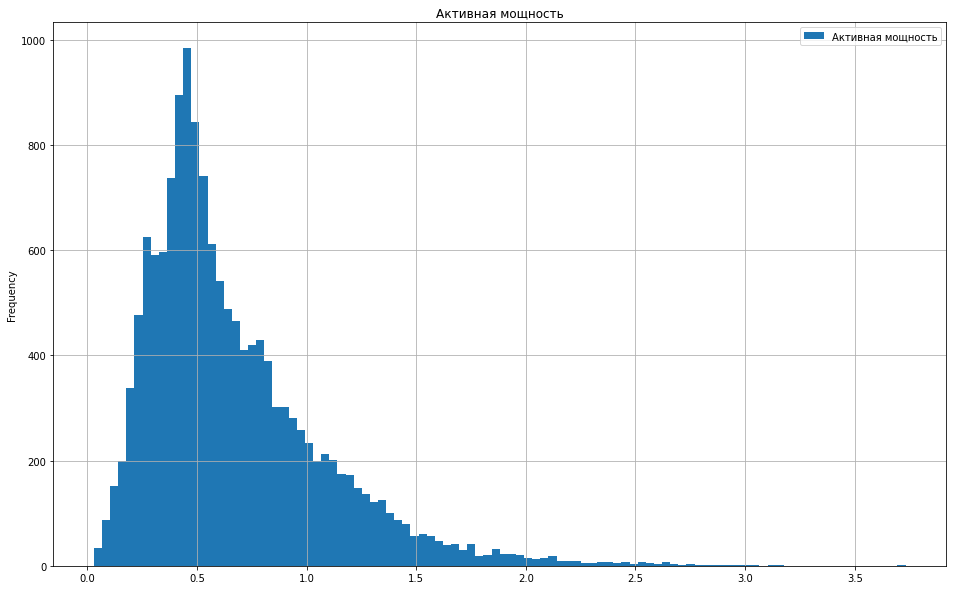

In [9]:
display(data_arc['Активная мощность'].describe())

data_arc['Активная мощность'].plot.hist(bins=100, figsize=(16,10), title='Активная мощность', legend=True, grid=True)
plt.show()

In [10]:
display(data_arc['Реактивная мощность'].describe())

count    14876.000000
mean         0.452592
std          5.878702
min       -715.504924
25%          0.290991
50%          0.415962
75%          0.637371
max          2.676388
Name: Реактивная мощность, dtype: float64

Посмотрим на данные, где реактивная мощность положительна

count    14875.000000
mean         0.500723
std          0.310880
min          0.020806
25%          0.291003
50%          0.415984
75%          0.637403
max          2.676388
Name: Реактивная мощность, dtype: float64

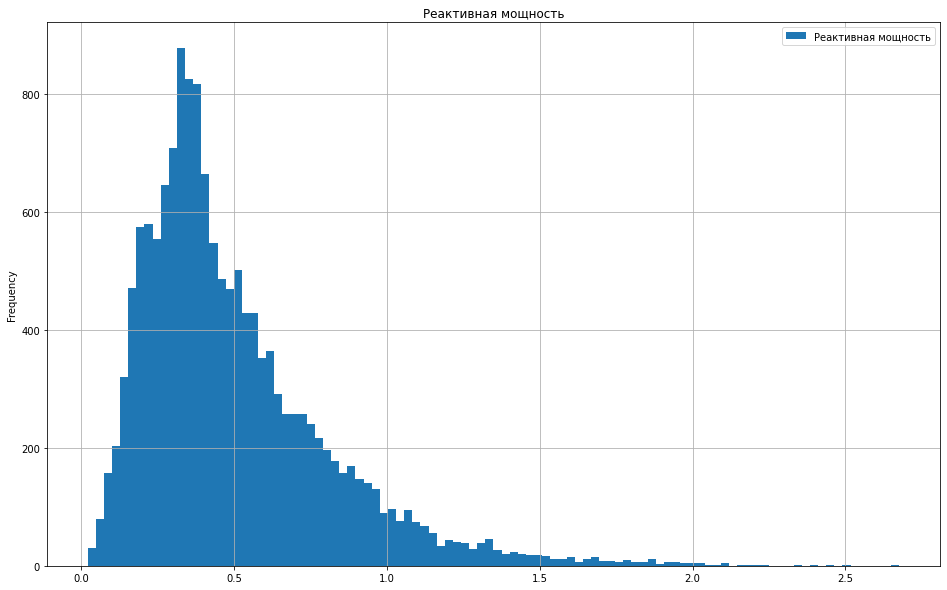

In [11]:
display(data_arc[data_arc['Реактивная мощность'] > 0]['Реактивная мощность'].describe())

data_arc[data_arc['Реактивная мощность'] > 0]['Реактивная мощность'].plot.hist(bins=100, figsize=(16,10), legend=True, grid=True, title='Реактивная мощность')
plt.show()

### Данные о подаче сыпучих материалов (объём)

In [12]:
data_bulk = pd.read_csv('/datasets/final_steel/data_bulk.csv')

Посмотрим на таблицу и информацию о ней

In [13]:
data_bulk.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [14]:
data_bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


Посмотрим на уникальные значения столбцов таблицы

In [15]:
show_rows(data_bulk)

Уникальные значения столбца key
[   1    2    3 ... 3239 3240 3241]
Уникальные значения столбца Bulk 1
[ 10.  16.  19.  21.  22.  24.  26.  27.  28.  29.  30.  31.  32.  33.
  34.  36.  37.  38.  39.  41.  43.  44.  46.  47.  48.  50.  51.  52.
  54.  58.  60.  62.  63.  65.  67.  69.  73.  74.  75.  78.  83.  90.
  92.  94. 104. 118. 185.  nan]
Уникальные значения столбца Bulk 2
[228. 232. 233. 236. 242. 246. 247. 248. 249. 254. 257. 258. 270. 282.
 325.  nan]
Уникальные значения столбца Bulk 3
[  6.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.  28.  29.
  30.  31.  32.  34.  36.  37.  38.  39.  40.  41.  42.  43.  44.  45.
  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.
  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.  70.  71.  72.  73.
  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.
  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.  98.  99. 100. 101.
 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112. 113. 114. 115.
 1

In [16]:
len(data_bulk['key'].unique())

3129

In [17]:
data_bulk['key'].value_counts()

2049    1
2612    1
2588    1
541     1
2590    1
       ..
1090    1
3139    1
1092    1
3141    1
2047    1
Name: key, Length: 3129, dtype: int64

In [18]:
for column in data_bulk.columns:
    if column[0] == 'B':
        print(column)
        display(data_bulk[column].describe())

Bulk 1


count    252.000000
mean      39.242063
std       18.277654
min       10.000000
25%       27.000000
50%       31.000000
75%       46.000000
max      185.000000
Name: Bulk 1, dtype: float64

Bulk 2


count     22.000000
mean     253.045455
std       21.180578
min      228.000000
25%      242.000000
50%      251.500000
75%      257.750000
max      325.000000
Name: Bulk 2, dtype: float64

Bulk 3


...

count     18.000000
mean     181.111111
std       46.088009
min      151.000000
25%      153.250000
50%      155.500000
75%      203.500000
max      305.000000
Name: Bulk 13, dtype: float64

Bulk 14


count    2806.000000
mean      170.284747
std        65.868652
min        16.000000
25%       119.000000
50%       151.000000
75%       205.750000
max       636.000000
Name: Bulk 14, dtype: float64

Bulk 15


count    2248.000000
mean      160.513345
std        51.765319
min         1.000000
25%       105.000000
50%       160.000000
75%       205.000000
max       405.000000
Name: Bulk 15, dtype: float64

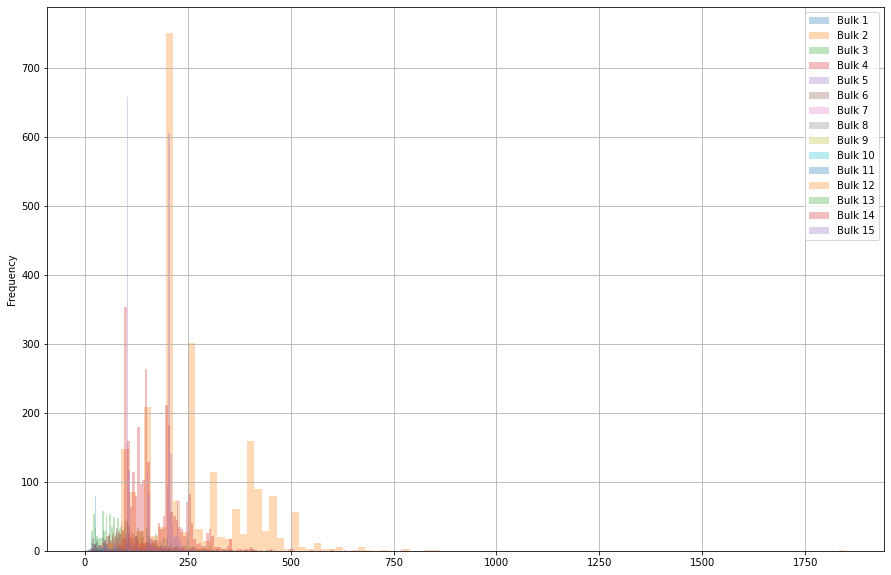

In [19]:
for column in data_bulk.columns:
    if column[0] == 'B':
        data_bulk[column].plot.hist(bins=100, figsize=(15,10), alpha=0.3, grid=True, legend=True)

### Данные о подаче сыпучих материалов (время)

In [20]:
data_bulk_time = pd.read_csv('/datasets/final_steel/data_bulk_time.csv')

Посмотрим на таблицу и информацию о ней

In [21]:
data_bulk_time.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:21:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:03:52,NaN,2019-05-03 11:03:52,2019-05-03 11:03:52
1,2,NaN,NaN,NaN,2019-05-03 11:46:38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:40:20,NaN,2019-05-03 11:40:20,2019-05-03 11:40:20
2,3,NaN,NaN,NaN,2019-05-03 12:31:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:09:40,NaN,2019-05-03 12:09:40,2019-05-03 12:09:40
3,4,NaN,NaN,NaN,2019-05-03 12:48:43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:41:24,NaN,2019-05-03 12:41:24,2019-05-03 12:41:24
4,5,NaN,NaN,NaN,2019-05-03 13:18:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:12:56,NaN,2019-05-03 13:12:56,2019-05-03 13:12:56


In [22]:
data_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB


Посмотрим на уникальные значения в столбцах таблицы

In [23]:
show_rows(data_bulk_time)

Уникальные значения столбца key
[   1    2    3 ... 3239 3240 3241]
Уникальные значения столбца Bulk 1
['2019-05-03 17:50:19' '2019-05-05 10:09:13' '2019-05-05 11:01:42'
 '2019-05-05 11:59:23' '2019-05-05 13:13:45' '2019-05-05 14:17:04'
 '2019-05-05 15:03:54' '2019-05-05 16:00:33' '2019-05-05 20:49:32'
 '2019-05-07 11:24:41' '2019-05-07 15:37:52' '2019-05-07 16:15:34'
 '2019-05-07 17:35:13' '2019-05-08 01:00:11' '2019-05-08 05:26:23'
 '2019-05-08 10:05:03' '2019-05-08 10:39:56' '2019-05-08 11:33:17'
 '2019-05-08 15:14:16' '2019-05-09 04:35:17' '2019-05-10 16:46:26'
 '2019-05-10 17:16:52' '2019-05-10 18:41:05' '2019-05-10 20:05:32'
 '2019-05-11 10:46:17' '2019-05-11 12:15:55' '2019-05-11 17:50:54'
 '2019-05-12 15:36:08' '2019-05-12 16:43:26' '2019-05-12 21:33:11'
 '2019-05-13 13:14:48' '2019-05-13 14:36:57' '2019-05-14 12:01:34'
 '2019-05-14 14:09:52' '2019-05-14 16:24:02' '2019-05-14 21:58:07'
 '2019-05-15 09:27:40' '2019-05-15 15:05:04' '2019-05-15 21:42:31'
 '2019-05-15 23:52:57' '20

In [24]:
len(data_bulk_time['key'].unique())

3129

In [25]:
data_bulk_time['key'].value_counts()

2049    1
2612    1
2588    1
541     1
2590    1
       ..
1090    1
3139    1
1092    1
3141    1
2047    1
Name: key, Length: 3129, dtype: int64

### Данные о продувке сплава газом

In [26]:
data_gas = pd.read_csv('/datasets/final_steel/data_gas.csv')

Посмотрим на таблицу и информацию о ней

In [27]:
data_gas.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [28]:
data_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


Посмотрим на уникальные значения в столбцах таблицы

In [29]:
show_rows(data_gas)

Уникальные значения столбца key
[   1    2    3 ... 3239 3240 3241]
Уникальные значения столбца Газ 1
[8.39852910e-03 1.66956024e-02 2.63028954e-01 ... 5.21423726e+01
 6.09356892e+01 7.79950397e+01]


In [30]:
len(data_gas['key'].unique())

3239

In [31]:
data_gas['key'].value_counts()

2049    1
3135    1
3115    1
1070    1
3119    1
       ..
2596    1
549     1
2600    1
553     1
2047    1
Name: key, Length: 3239, dtype: int64

count    3239.000000
mean       11.002062
std         6.220327
min         0.008399
25%         7.043089
50%         9.836267
75%        13.769915
max        77.995040
Name: Газ 1, dtype: float64

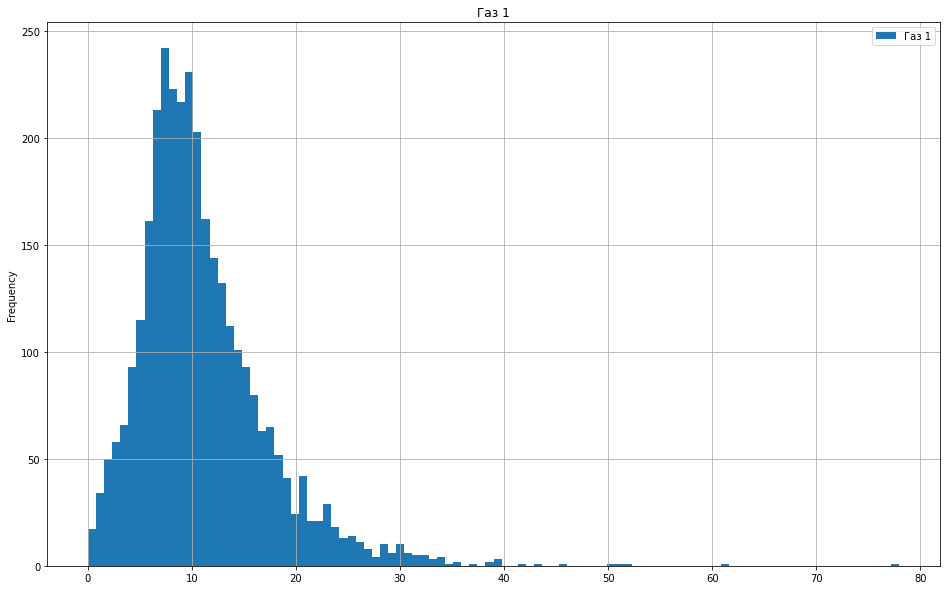

In [32]:
display(data_gas['Газ 1'].describe())

data_gas['Газ 1'].plot.hist(bins=100, figsize=(16,10), grid=True, legend=True, title='Газ 1')
plt.show()

### Результаты измерения температуры

In [33]:
data_temp = pd.read_csv('/datasets/final_steel/data_temp.csv')

Посмотрим на таблицу и информацию о ней

In [34]:
data_temp.head()

,key,Время замера,Температура
0,1,2019-05-03 11:16:18,1571.0
1,1,2019-05-03 11:25:53,1604.0
2,1,2019-05-03 11:29:11,1618.0
3,1,2019-05-03 11:30:01,1601.0
4,1,2019-05-03 11:30:39,1613.0


In [35]:
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15907 entries, 0 to 15906
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           15907 non-null  int64  
 1   Время замера  15907 non-null  object 
 2   Температура   13006 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 372.9+ KB


Посмотрим на уникальные значения в столбцах таблицы

In [36]:
show_rows(data_temp)

Уникальные значения столбца key
[   1    2    3 ... 3239 3240 3241]
Уникальные значения столбца Время замера
['2019-05-03 11:16:18' '2019-05-03 11:25:53' '2019-05-03 11:29:11' ...
 '2019-09-01 04:22:39' '2019-09-01 04:33:42' '2019-09-01 04:38:08']
Уникальные значения столбца Температура
[1191. 1204. 1208. 1218. 1227. 1383. 1519. 1520. 1525. 1526. 1527. 1528.
 1529. 1530. 1531. 1532. 1533. 1534. 1535. 1536. 1537. 1538. 1539. 1540.
 1541. 1542. 1543. 1544. 1545. 1546. 1547. 1548. 1549. 1550. 1551. 1552.
 1553. 1554. 1555. 1556. 1557. 1558. 1559. 1560. 1561. 1562. 1563. 1564.
 1565. 1566. 1567. 1568. 1569. 1570. 1571. 1572. 1573. 1574. 1575. 1576.
 1577. 1578. 1579. 1580. 1581. 1582. 1583. 1584. 1585. 1586. 1587. 1588.
 1589. 1590. 1591. 1592. 1593. 1594. 1595. 1596. 1597. 1598. 1599. 1600.
 1601. 1602. 1603. 1604. 1605. 1606. 1607. 1608. 1609. 1610. 1611. 1612.
 1613. 1614. 1615. 1616. 1617. 1618. 1619. 1620. 1621. 1622. 1623. 1624.
 1625. 1626. 1627. 1628. 1629. 1630. 1631. 1632. 1633. 

In [37]:
len(data_temp['key'].unique())

3216

In [38]:
data_temp['key'].value_counts()

46      16
1214    16
1513    16
44      16
1689    15
        ..
1415     2
1836     2
2456     2
195      1
279      1
Name: key, Length: 3216, dtype: int64

count    13006.000000
mean      1591.840920
std         21.375851
min       1191.000000
25%       1581.000000
50%       1591.000000
75%       1601.000000
max       1705.000000
Name: Температура, dtype: float64

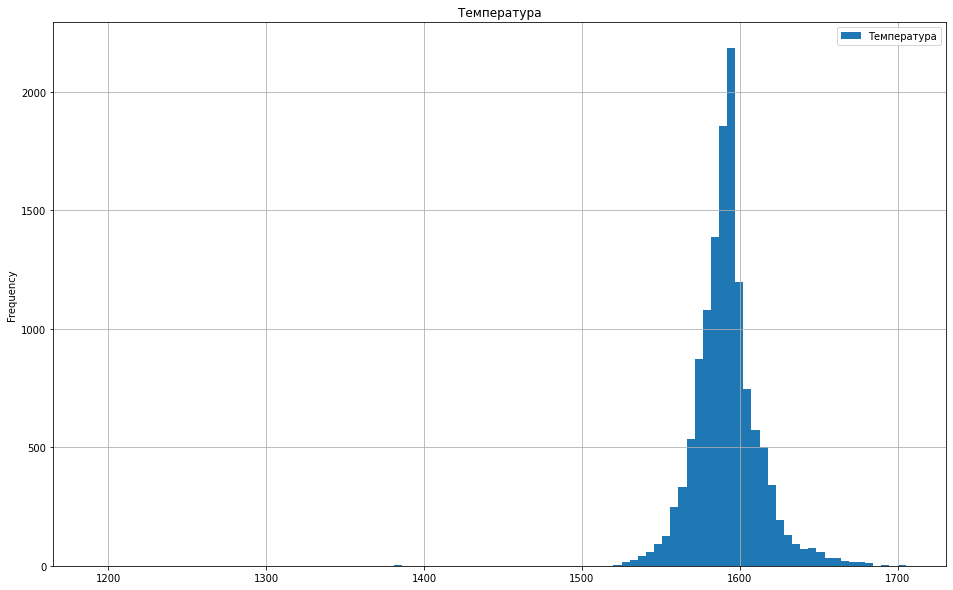

In [39]:
display(data_temp['Температура'].describe())

data_temp['Температура'].plot.hist(bins=100, figsize=(16,10), legend=True, grid=True, title='Температура')
plt.show()

### Данные о проволочных материалах (объём)

In [40]:
data_wire = pd.read_csv('/datasets/final_steel/data_wire.csv')

Посмотрим на таблицу и информацию о ней

In [41]:
data_wire.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
data_wire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


In [43]:
len(data_wire['key'].unique())

3081

In [44]:
data_wire['key'].value_counts()

2049    1
2664    1
2590    1
543     1
2592    1
       ..
1090    1
3139    1
1092    1
3141    1
2047    1
Name: key, Length: 3081, dtype: int64

In [45]:
for column in data_wire.columns:
    if column[0] == 'W':
        print(column)
        display(data_wire[column].describe())

Wire 1


count    3055.000000
mean      100.895853
std        42.012518
min         1.918800
25%        72.115684
50%       100.158234
75%       126.060483
max       330.314424
Name: Wire 1, dtype: float64

Wire 2


count    1079.000000
mean       50.577323
std        39.320216
min         0.030160
25%        20.193680
50%        40.142956
75%        70.227558
max       282.780152
Name: Wire 2, dtype: float64

Wire 3


...

count    11.000000
mean     10.039007
std       8.610584
min       0.234208
25%       6.762756
50%       9.017009
75%      11.886057
max      32.847674
Name: Wire 7, dtype: float64

Wire 8


count     19.000000
mean      53.625193
std       16.881728
min       45.076721
25%       46.094879
50%       46.279999
75%       48.089603
max      102.762401
Name: Wire 8, dtype: float64

Wire 9


count    29.000000
mean     34.155752
std      19.931616
min       4.622800
25%      22.058401
50%      30.066399
75%      43.862003
max      90.053604
Name: Wire 9, dtype: float64

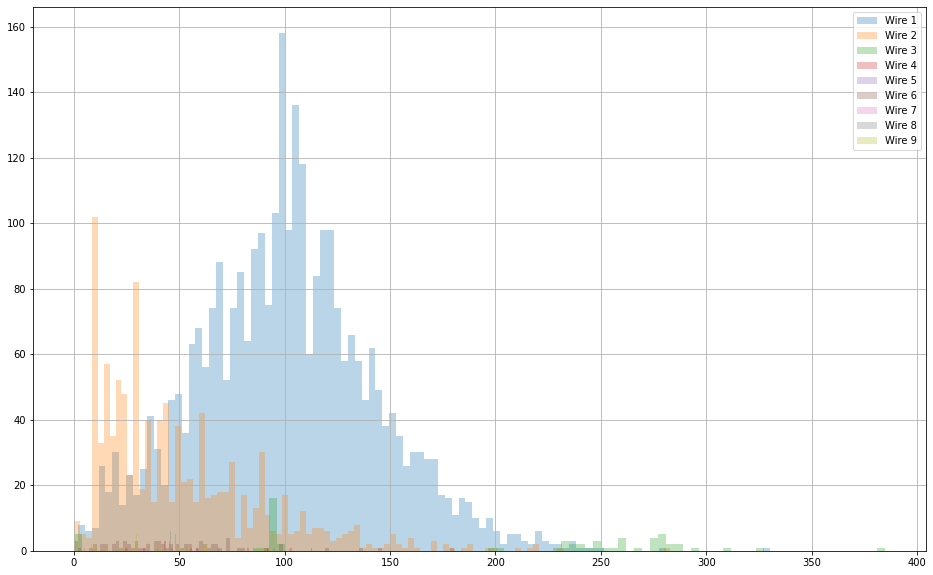

In [46]:
for column in data_wire.columns:
    if column[0] == 'W':
        data_wire[column].hist(bins=100, figsize=(16,10), alpha=0.3, legend=True, grid=True)

### Данные о проволочных материалах (время)

In [47]:
data_wire_time = pd.read_csv('/datasets/final_steel/data_wire_time.csv')

Посмотрим на таблицу и информацию о ней

In [48]:
data_wire_time.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:11:41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:46:10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:13:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:48:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:18:15,2019-05-03 13:32:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
data_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


Посмотрим на уникальные значения в столбцах таблицы

In [50]:
show_rows(data_wire_time)

Уникальные значения столбца key
[   1    2    3 ... 3239 3240 3241]
Уникальные значения столбца Wire 1
['2019-05-03 11:11:41' '2019-05-03 11:46:10' '2019-05-03 12:13:47' ...
 '2019-09-01 03:12:02' '2019-09-01 04:16:01' nan]
Уникальные значения столбца Wire 2
['2019-05-03 13:32:06' '2019-05-03 13:59:54' '2019-05-03 15:58:12' ...
 '2019-08-31 13:14:22' '2019-08-31 18:50:15' nan]
Уникальные значения столбца Wire 3
['2019-05-04 04:47:53' '2019-05-04 05:40:08' '2019-05-07 08:50:29'
 '2019-05-07 10:17:14' '2019-05-07 15:50:31' '2019-05-07 16:34:12'
 '2019-05-07 17:43:23' '2019-05-07 21:58:49' '2019-05-07 22:40:07'
 '2019-05-07 23:27:46' '2019-05-18 13:04:48' '2019-05-18 13:41:36'
 '2019-05-18 20:52:18' '2019-05-18 21:49:12' '2019-06-02 20:37:44'
 '2019-06-08 16:23:31' '2019-06-10 13:19:54' '2019-06-10 14:05:33'
 '2019-06-10 14:25:42' '2019-06-12 01:29:02' '2019-06-12 20:11:25'
 '2019-06-12 21:27:01' '2019-07-07 18:33:17' '2019-07-07 19:25:35'
 '2019-07-07 20:16:17' '2019-07-08 17:20:59' '201

In [51]:
len(data_wire_time['key'].unique())

3081

In [52]:
data_wire_time['key'].value_counts()

2049    1
2664    1
2590    1
543     1
2592    1
       ..
1090    1
3139    1
1092    1
3141    1
2047    1
Name: key, Length: 3081, dtype: int64

### Вывод по пункту 1

    1) Имена столбцов нужно превести к английском языку прописными буквами и избавиться от пробелов.
    2) Необходим перевод времени в формат datetime.
    3) Есть столбцы, которые могут не использовать тип float, так как хранят только целые числа.
    4) Аномальное значение реактивной мощности в таблице data_arc

        В таблицах разное количество уникальных номеров партии key. Это может означать, что данные по партии могут быть утеряны или над ней не выполнялся технологический этап.

        Пропуски значений в столбцах (это ошибка датчика, который не передал информацию или отсутствие действия/замера на этой стадии). 

        В таблицах data_bulk и data_wire указаны 15 и 9 столбцов о различных материалах. Это значит, что в каждую партию может идти определенный набор из них.

        Данные требуют предобработки и группировки по признаку key. 

        Данные об активной и реактивной мощности распределены со смещением влево, данные о температуре распределены без смещения.

## Подготовка данных


    Найдем суммы значений активной и реактивной мощности
    Найдем все записи по температурам, где есть минимум два значения температуры и создадим новую таблицу из первого и последнего замера.
    Значения столбца key переведем в индексы датафреймов.
    Заполним nan значения 0 для таблиц data_bulk и data_wire.
    Приведем типы данных
    Разобьем данные на train/test в соотношении 3/2


Составим из таблицы data_arc сгрупированную таблицу data_arc_sum по key для дальнейшего объединения данных.  
    
    (чем больше энергии было затрачено на нагрев, тем больше должна быть темпереатура)

In [53]:
data_arc.columns = ['key', 'start_time','end_time', 'active_power', 'reactive_power']

data_arc = data_arc.query('reactive_power > 0')

data_arc_sum = pd.pivot_table(data_arc,
                             values=['active_power','reactive_power'],
                             index='key',
                             aggfunc={'active_power': np.sum,
                                      'reactive_power': np.sum})

In [54]:
data_arc_sum.columns = ['sum_active_power','sum_reactive_power']
data_arc_sum.head()

,sum_active_power,sum_reactive_power
key,,
1,4.878147,3.183241
2,3.052598,1.998112
3,2.525882,1.599076
4,3.209250,2.060298
5,3.347173,2.252643


Удалим из таблицы партии key, которые не подходят по следующим условиям:

    Нет финального замера. Когда температуру замеряли до окончания последней операции нагрева дугой
    Только один замер температуры.

In [55]:
bad_keys = []

for key in list(data_temp['key'].unique()):
    try:
        if ((data_temp[data_temp['key'] == key]['Время замера'].max() < 
            data_arc[data_arc['key'] == key]['end_time'].max()) or
           (data_temp[data_temp['key'] == key]['Время замера'].max() == 
            data_temp[data_temp['key'] == key]['Время замера'].min())):
            bad_keys.append(key)
    except:
        bad_keys.append(key)

print("Количество неподходящих key:", len(bad_keys))
print(bad_keys)

Количество неподходящих key: 171
[11, 38, 43, 51, 64, 69, 73, 81, 177, 179, 180, 182, 185, 195, 213, 216, 220, 222, 267, 271, 279, 293, 296, 297, 321, 325, 326, 444, 445, 448, 453, 456, 470, 471, 472, 491, 535, 562, 586, 587, 588, 590, 592, 593, 596, 616, 638, 641, 704, 731, 733, 741, 757, 786, 869, 870, 874, 878, 928, 929, 932, 934, 997, 1057, 1060, 1152, 1153, 1161, 1232, 1313, 1316, 1341, 1371, 1381, 1402, 1433, 1458, 1461, 1464, 1493, 1505, 1558, 1578, 1618, 1622, 1623, 1624, 1639, 1657, 1683, 1685, 1712, 1713, 1720, 1724, 1811, 1813, 1837, 1872, 1873, 1876, 1946, 1949, 1964, 1966, 1987, 1989, 1990, 1992, 1993, 1994, 2053, 2078, 2138, 2140, 2142, 2143, 2152, 2211, 2221, 2261, 2263, 2265, 2300, 2303, 2389, 2390, 2393, 2398, 2425, 2427, 2451, 2457, 2522, 2540, 2543, 2544, 2572, 2601, 2604, 2606, 2667, 2670, 2671, 2695, 2698, 2736, 2743, 2787, 2808, 2809, 2814, 2838, 2842, 2843, 2862, 2898, 2951, 2960, 2988, 3044, 3047, 3146, 3153, 3156, 3187, 3204, 3209, 3211, 3212, 3216]


Удалим все строки с пропусками и посмотрим информацию о таблице

In [56]:
data_temp = data_temp.query('key not in @bad_keys')
data_temp = data_temp.dropna()
data_temp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12381 entries, 0 to 15902
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           12381 non-null  int64  
 1   Время замера  12381 non-null  object 
 2   Температура   12381 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 386.9+ KB


In [57]:
count_of_bad_keys = (data_temp['key'].value_counts() < 2).sum() 

good_keys = list(data_temp['key'].value_counts().index[:-count_of_bad_keys])
data_temp = data_temp.query('key in @good_keys')

data_temp['key'].value_counts()

1214    16
1513    16
46      16
44      16
2108    15
        ..
1801     2
35       2
1894     2
2194     2
800      2
Name: key, Length: 2344, dtype: int64

In [58]:
data_temp.columns = ['key', 'time','temp']
pt_data_temp = pd.pivot_table(data_temp,
                                values='time',
                                index='key',
                                aggfunc={'time': [np.min, np.max]})

Получен срез со значениями времени начального и конечного замера

In [59]:
pt_data_temp

,amax,amin
key,,
1,2019-05-03 11:30:39,2019-05-03 11:16:18
2,2019-05-03 11:59:12,2019-05-03 11:37:27
3,2019-05-03 12:34:57,2019-05-03 12:13:17
4,2019-05-03 12:59:25,2019-05-03 12:52:57
5,2019-05-03 13:36:01,2019-05-03 13:23:19
...,...,...
2495,2019-08-06 00:54:42,2019-08-06 00:35:45
2496,2019-08-06 01:29:52,2019-08-06 01:02:54
2497,2019-08-06 01:53:50,2019-08-06 01:41:53


Сформируем новый срез на основе времени и сохраним его в data_temp_final.

In [60]:
start_time_list = list(pt_data_temp['amin'])
end_time_list = list(pt_data_temp['amax'])
data_temp_start_temp = data_temp.query('time in @start_time_list ')
data_temp_start_temp = data_temp_start_temp.set_index('key')
data_temp_end_temp = data_temp.query('time in @end_time_list ')
data_temp_end_temp = data_temp_end_temp.set_index('key')
data_temp_final = data_temp_start_temp.copy()
data_temp_final.columns = ['time','start_temp']
data_temp_final['end_temp'] = data_temp_end_temp['temp']
data_temp_final = data_temp_final.drop('time', axis=1)

In [61]:
data_temp_final

,start_temp,end_temp
key,,
1,1571.0,1613.0
2,1581.0,1602.0
3,1596.0,1599.0
4,1601.0,1625.0
5,1576.0,1602.0
...,...,...
2495,1570.0,1591.0
2496,1554.0,1591.0
2497,1571.0,1589.0


В data_arc_sum, data_temp_final, data_bulk, data_gas и data_wire преобразуем index в значение столбца key

In [62]:
data_bulk = data_bulk.set_index('key')
data_bulk.columns = [f'bulk_{x}' for x in range(1,16)]
data_gas = data_gas.set_index('key')
data_gas.columns = ['gas']
data_wire = data_wire.set_index('key')
data_wire.columns = [f'wire_{x}' for x in range(1,10)]

    Наша цель - предсказывать значение end_temp. 
    Удалим партии, где нет информации о температуре. 

In [63]:
data_steel = pd.concat([data_arc_sum, data_temp_final, data_bulk, data_gas, data_wire], axis=1, sort=False)
data_steel = data_steel.dropna(subset=['end_temp'])

data_steel.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2344 entries, 1 to 2499
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sum_active_power    2344 non-null   float64
 1   sum_reactive_power  2344 non-null   float64
 2   start_temp          2344 non-null   float64
 3   end_temp            2344 non-null   float64
 4   bulk_1              189 non-null    float64
 5   bulk_2              13 non-null     float64
 6   bulk_3              931 non-null    float64
 7   bulk_4              758 non-null    float64
 8   bulk_5              53 non-null     float64
 9   bulk_6              433 non-null    float64
 10  bulk_7              13 non-null     float64
 11  bulk_8              1 non-null      float64
 12  bulk_9              13 non-null     float64
 13  bulk_10             130 non-null    float64
 14  bulk_11             124 non-null    float64
 15  bulk_12             1797 non-null   float64
 16  bulk_1

Столбец wire_5 удалим из-за отсуствия информации во всех запясях.

In [64]:
data_steel = data_steel.drop('wire_5',axis=1)

Приведем типы столбцов start_temp, end_temp и bulk составляющих к целому типу (так как там храняться только целые числа). Все NaN заполним значениями 0.

In [65]:
data_steel = data_steel.fillna(0)

data_steel['start_temp'] = pd.to_numeric(data_steel['start_temp'], downcast='integer')
data_steel['end_temp'] = pd.to_numeric(data_steel['end_temp'], downcast='integer')
for i in range(1,16):
    data_steel[f'bulk_{i}'] = pd.to_numeric(data_steel[f'bulk_{i}'], downcast='integer')

In [66]:
data_steel.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2344 entries, 1 to 2499
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sum_active_power    2344 non-null   float64
 1   sum_reactive_power  2344 non-null   float64
 2   start_temp          2344 non-null   int16  
 3   end_temp            2344 non-null   int16  
 4   bulk_1              2344 non-null   int16  
 5   bulk_2              2344 non-null   int16  
 6   bulk_3              2344 non-null   int16  
 7   bulk_4              2344 non-null   int16  
 8   bulk_5              2344 non-null   int16  
 9   bulk_6              2344 non-null   int16  
 10  bulk_7              2344 non-null   int16  
 11  bulk_8              2344 non-null   int8   
 12  bulk_9              2344 non-null   int16  
 13  bulk_10             2344 non-null   int16  
 14  bulk_11             2344 non-null   int16  
 15  bulk_12             2344 non-null   int16  
 16  bulk_1

***Изучим распределение данных.***

<AxesSubplot:>

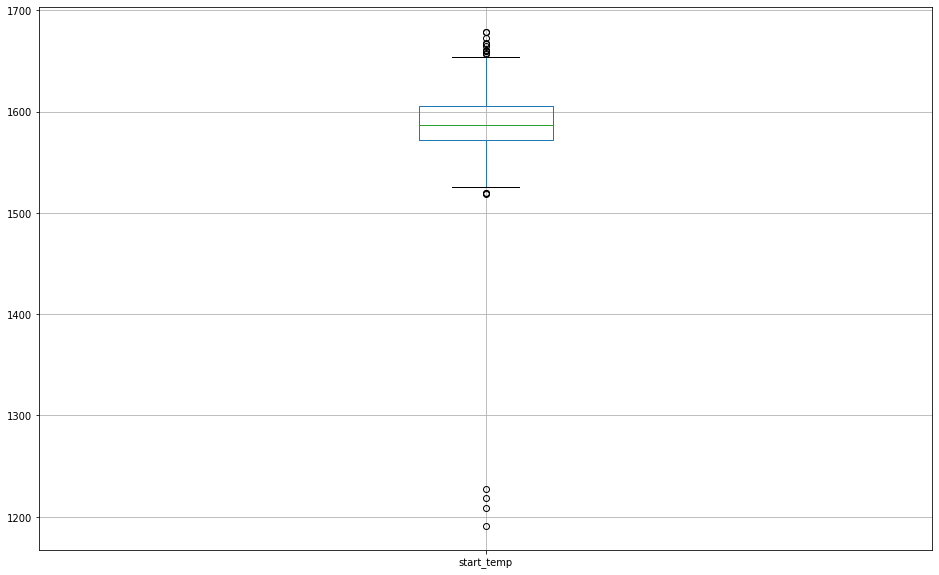

In [67]:
data_steel.boxplot(column='start_temp', figsize=(16,10))

<AxesSubplot:>

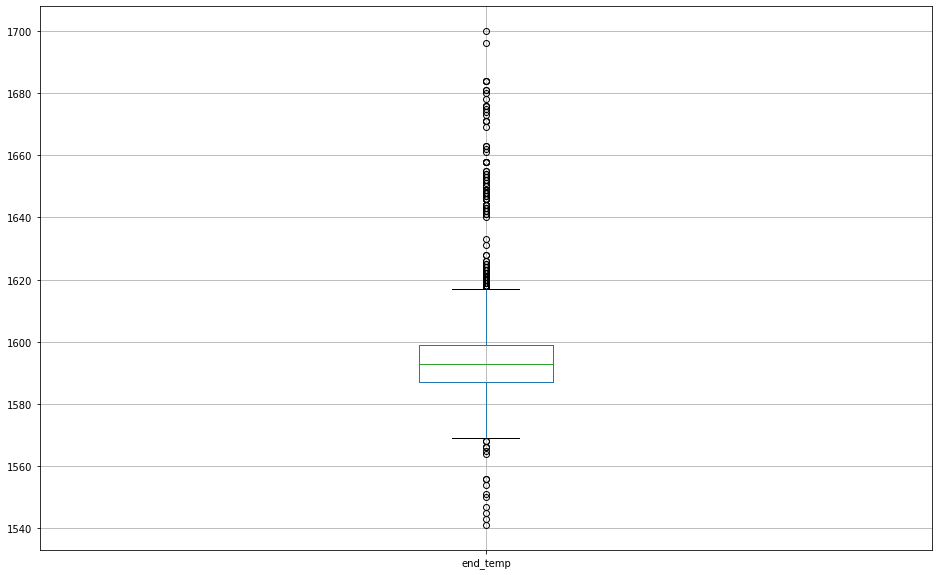

In [68]:
data_steel.boxplot(column='end_temp', figsize=(16,10))

<AxesSubplot:>

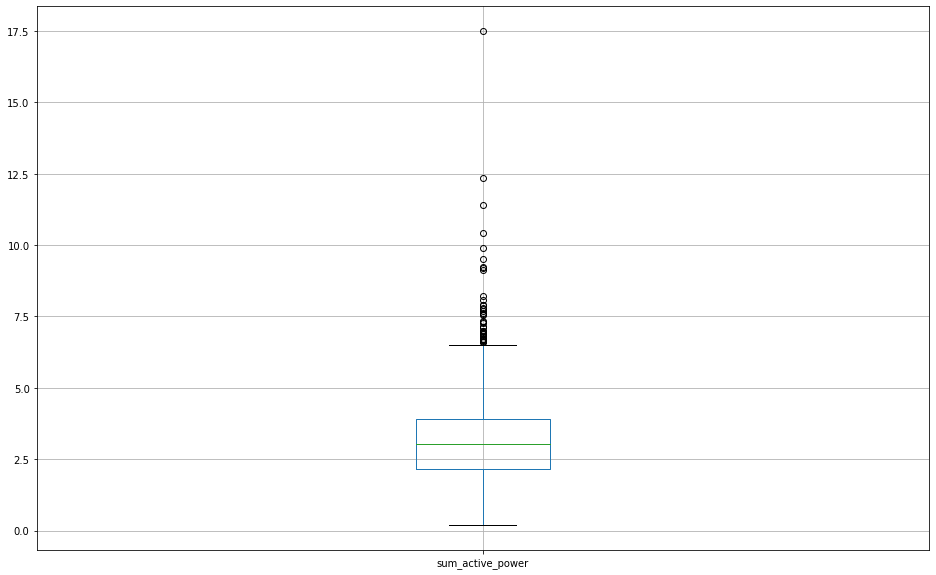

In [69]:
data_steel.boxplot(column='sum_active_power', figsize=(16,10))

<AxesSubplot:>

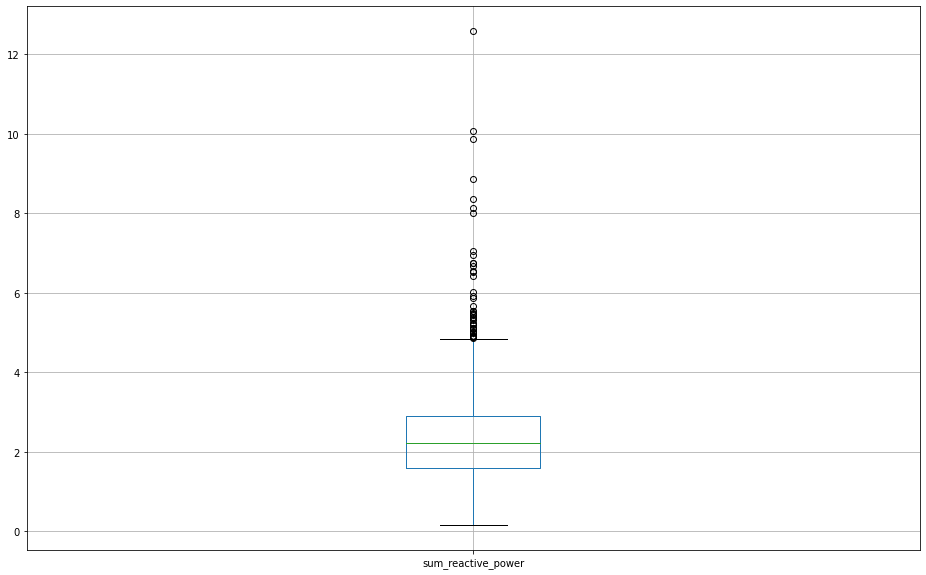

In [70]:
data_steel.boxplot(column='sum_reactive_power', figsize=(16,10))

<AxesSubplot:>

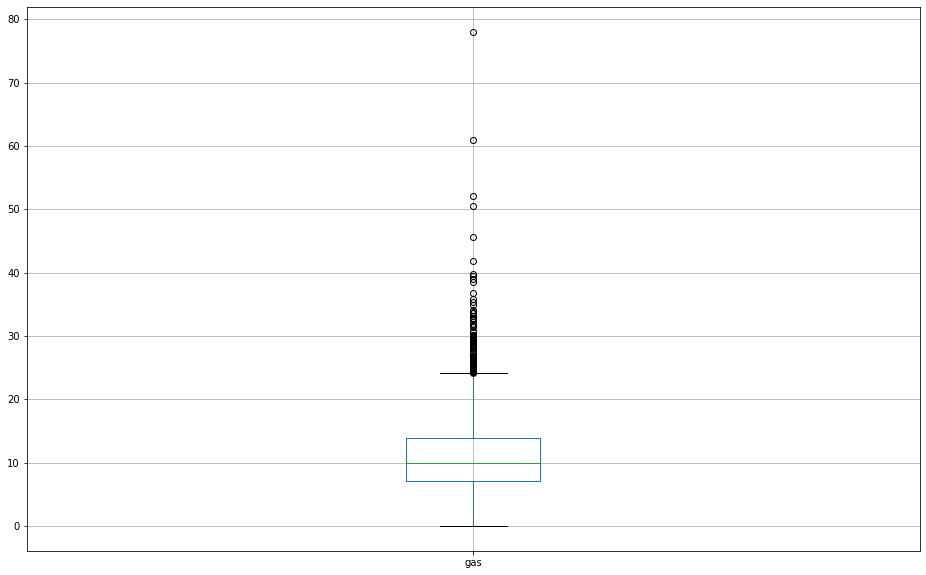

In [71]:
data_steel.boxplot(column='gas', figsize=(16,10))

Выполним оценку мультиколлинеарности и отсутсвие зависимостей между целевым признаком и остальными.

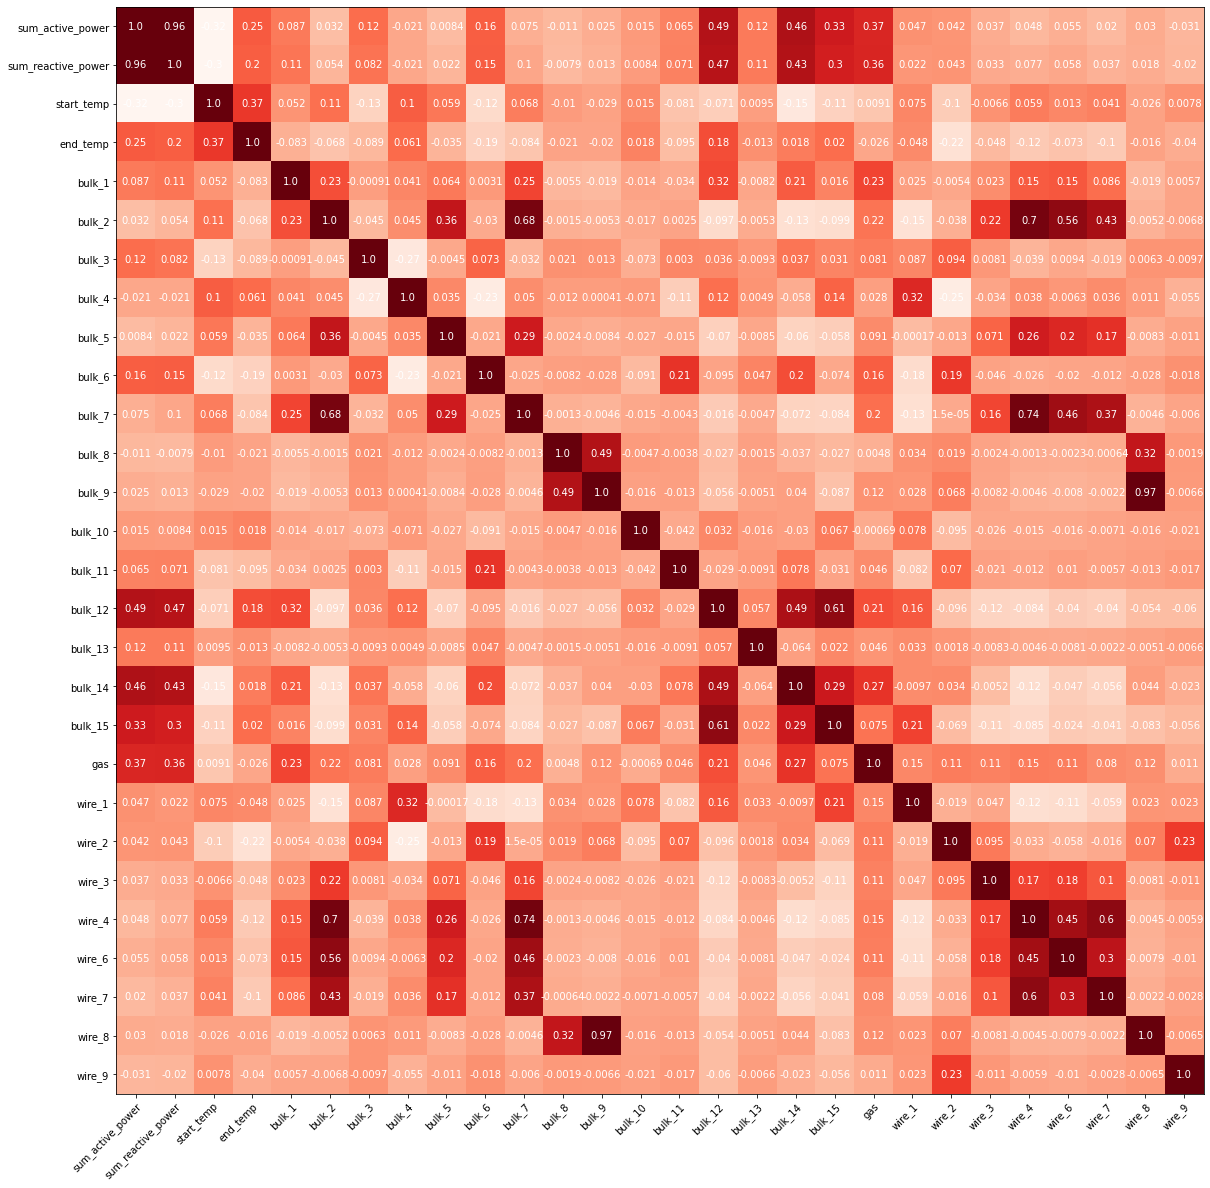

In [72]:
data_steel_knn = data_steel.copy()
corr_heatmap_data = data_steel_knn.corr()

fig, ax = plt.subplots(figsize=(20,20))
ax.set_xticks(np.arange(len(corr_heatmap_data.index)))
ax.set_yticks(np.arange(len(corr_heatmap_data.index)))

ax.set_xticklabels(corr_heatmap_data.index)
ax.set_yticklabels(corr_heatmap_data.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

data = corr_heatmap_data.values

for i in range(len(corr_heatmap_data.index)):
    for j in range(len(corr_heatmap_data.index)):
        text = ax.text(j, i, '{:.2}'.format(data[i, j]),
                       ha="center", va="center", color="w")
        
im = ax.imshow(corr_heatmap_data.corr(), cmap='Reds')

Видно, что есть сильные прямопропоциональные зависимости между sum_active_power и sum_reactive_power и bulk_9 и wire_8. Так как они дублируют по сути друг друга, удалим из обучения sum_reactive_power и wire_8.

In [73]:
data_steel_knn = data_steel_knn.drop(['sum_reactive_power', 'wire_8'], axis=1)

Оценим, какие столбцы влияют на результат end_temp.

In [74]:
data_steel_knn.corr()['end_temp'] 

sum_active_power    0.247650
start_temp          0.366398
end_temp            1.000000
bulk_1             -0.082638
bulk_2             -0.067612
bulk_3             -0.088806
bulk_4              0.061157
bulk_5             -0.034697
bulk_6             -0.188054
bulk_7             -0.084039
bulk_8             -0.021390
bulk_9             -0.020254
bulk_10             0.018222
bulk_11            -0.095105
bulk_12             0.180171
bulk_13            -0.012884
bulk_14             0.017625
bulk_15             0.019843
gas                -0.025723
wire_1             -0.048129
wire_2             -0.215639
wire_3             -0.048014
wire_4             -0.121044
wire_6             -0.073452
wire_7             -0.100990
wire_9             -0.039511
Name: end_temp, dtype: float64

Видно, что не все столбцы значимо влияют на данные. Для выявления аномалий возьмем те, чья корреляция больше 10%

In [75]:
data_steel_knn.corr()['end_temp'].abs() >= 0.1

sum_active_power     True
start_temp           True
end_temp             True
bulk_1              False
bulk_2              False
bulk_3              False
bulk_4              False
bulk_5              False
bulk_6               True
bulk_7              False
bulk_8              False
bulk_9              False
bulk_10             False
bulk_11             False
bulk_12              True
bulk_13             False
bulk_14             False
bulk_15             False
gas                 False
wire_1              False
wire_2               True
wire_3              False
wire_4               True
wire_6              False
wire_7               True
wire_9              False
Name: end_temp, dtype: bool

In [76]:
model = KNN()
data_steel_have_anomaly = data_steel_knn[['sum_active_power',
                                          'start_temp',
                                          'end_temp',
                                          'bulk_6',
                                          'bulk_12',
                                          'wire_2',
                                          'wire_4',
                                          'wire_7']]
model.fit(data_steel_have_anomaly)
data_steel_have_anomaly['is_outlier'] =  model.predict(data_steel_have_anomaly) == 1
outliers_knn = data_steel_have_anomaly['is_outlier'].sum()
print("Количество аномалий (KNN): ", outliers_knn)

outlier_indexes = list(data_steel_have_anomaly[data_steel_have_anomaly['is_outlier'] == 1].index)
good_indexes = list(set(data_steel_have_anomaly.index) - set(outlier_indexes))

data_steel_knn = data_steel_knn.drop(outlier_indexes)
data_steel_knn.shape

Количество аномалий (KNN):  196


(2148, 26)

### Вывод по пункту 2

    Данные были подготовлены для обучения модели.
    Целевым признаком является столбец end_temp. 

## Обучение модели

Разобьем данные на train и test к соотношению 3/2

In [77]:
random_state = 12345

features = data_steel_knn.drop('end_temp', axis=1)
target = data_steel_knn['end_temp']

features_train, features_test, target_train, target_test = train_test_split(
                                                            features, 
                                                            target, 
                                                            test_size=0.25, 
                                                            random_state=random_state)
cv_counts = 5

***LinearRegression***

In [78]:
%%time

regressor = LinearRegression()
print()

cv_MAE_LR = (cross_val_score(regressor, 
                             features_train, 
                             target_train, 
                             cv=cv_counts, 
                             scoring='neg_mean_absolute_error').mean() * -1)

print('Среднее значение MAE = ', cv_MAE_LR)


Среднее значение MAE =  7.647884400270078
CPU times: user 215 ms, sys: 250 ms, total: 465 ms
Wall time: 444 ms


***RandomForestRegressor***

In [79]:
%%time

regressor = RandomForestRegressor() 
hyperparams = [{'criterion':['mse'],
                'n_estimators':[x for x in range(100, 1001, 50)], 
                'random_state':[random_state]}]

print('Настройка гиперпараметров')
print()

clf = GridSearchCV(regressor, hyperparams, scoring='neg_mean_absolute_error', cv=cv_counts)
clf.fit(features_train, target_train)

print("Лучший набор параметров")
print()

best_params_RFR = clf.best_params_
print(clf.best_params_)
print()
print()

means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.6f for %r"% ((mean*-1), params))
print()

cv_MAE_RFR = (max(means)*-1)

Настройка гиперпараметров

Лучший набор параметров

{'criterion': 'mse', 'n_estimators': 850, 'random_state': 12345}


6.155988 for {'criterion': 'mse', 'n_estimators': 100, 'random_state': 12345}
6.145319 for {'criterion': 'mse', 'n_estimators': 150, 'random_state': 12345}
6.146206 for {'criterion': 'mse', 'n_estimators': 200, 'random_state': 12345}
6.145505 for {'criterion': 'mse', 'n_estimators': 250, 'random_state': 12345}
6.135812 for {'criterion': 'mse', 'n_estimators': 300, 'random_state': 12345}
6.131557 for {'criterion': 'mse', 'n_estimators': 350, 'random_state': 12345}
6.129082 for {'criterion': 'mse', 'n_estimators': 400, 'random_state': 12345}
6.128503 for {'criterion': 'mse', 'n_estimators': 450, 'random_state': 12345}
6.132307 for {'criterion': 'mse', 'n_estimators': 500, 'random_state': 12345}
6.130404 for {'criterion': 'mse', 'n_estimators': 550, 'random_state': 12345}
6.131560 for {'criterion': 'mse', 'n_estimators': 600, 'random_state': 12345}
6.131013 for {'criterio

***CatBoostRegressor***

In [80]:
%%time

regressor = CatBoostRegressor(verbose=False, random_state=random_state)

print()

cv_MAE_CBR = (cross_val_score(regressor, 
                             features_train, 
                             target_train, 
                             cv=cv_counts, 
                             scoring='neg_mean_absolute_error').mean() * -1)

print('Среднее значение MAE = ', cv_MAE_CBR)


Среднее значение MAE =  5.859705871057433
CPU times: user 16.6 s, sys: 601 ms, total: 17.2 s
Wall time: 23.5 s


In [81]:
best_params_CBR = CatBoostRegressor(verbose=False, 
                                    random_state=random_state).fit(features_train, 
                                        target_train).get_all_params()
best_params_CBR

{'nan_mode': 'Min',
 'eval_metric': 'RMSE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': False,
 'random_seed': 12345,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'RMSE',
 'learning_rate': 0.04414699971675873,
 'score_function': 'Cosine',
 'task_t

***LGBMRegressor***

In [82]:
%%time

regressor = LGBMRegressor() 
hyperparams = [{'num_leaves':[x for x in range(10,31)], 
                'learning_rate':[x/100 for x in range(1, 11)],
                'random_state':[random_state]}]

print('Настройка гиперпараметров')
print()

clf = GridSearchCV(regressor, hyperparams, scoring='neg_mean_absolute_error', cv=cv_counts)
clf.fit(features_train, target_train)

print("Лучший набор параметров")
print()

best_params_LGBMR = clf.best_params_
print(clf.best_params_)
print()

means = clf.cv_results_['mean_test_score']
stds = clf.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, clf.cv_results_['params']):
    print("%0.6f for %r"% ((mean*-1), params))
print()

cv_MAE_LGBMR = (max(means)*-1)

Настройка гиперпараметров

Лучший набор параметров

{'learning_rate': 0.08, 'num_leaves': 10, 'random_state': 12345}

7.599275 for {'learning_rate': 0.01, 'num_leaves': 10, 'random_state': 12345}
7.553269 for {'learning_rate': 0.01, 'num_leaves': 11, 'random_state': 12345}
7.509853 for {'learning_rate': 0.01, 'num_leaves': 12, 'random_state': 12345}
7.475853 for {'learning_rate': 0.01, 'num_leaves': 13, 'random_state': 12345}
7.450304 for {'learning_rate': 0.01, 'num_leaves': 14, 'random_state': 12345}
7.430315 for {'learning_rate': 0.01, 'num_leaves': 15, 'random_state': 12345}
7.413837 for {'learning_rate': 0.01, 'num_leaves': 16, 'random_state': 12345}
7.397704 for {'learning_rate': 0.01, 'num_leaves': 17, 'random_state': 12345}
7.372368 for {'learning_rate': 0.01, 'num_leaves': 18, 'random_state': 12345}
7.351331 for {'learning_rate': 0.01, 'num_leaves': 19, 'random_state': 12345}
7.340316 for {'learning_rate': 0.01, 'num_leaves': 20, 'random_state': 12345}
7.327548 for {'learning_

### Вывод по пункту 3

    Были обучены модели для предсказания финальной температуры. 
    Произведен поиск гиперпараметров для получения лучшего результата.

## Тестирование моделей

Протестируем все модели для оценки их эффективности. Качественной оценкой будем считать выполнения двух условий:

    Наихудший показатель МАЕ < 8.7 - минимальная задача
    Идеальный показатель МАЕ < 6. - максимальная задача

In [83]:
%%time

model_LR = LinearRegression()
model_LR.fit(features_train, target_train)
target_predict_LR = model_LR.predict(features_test)
test_MAE_LR = mean_absolute_error(target_predict_LR, target_test)
print('LinearRegression')
print('MAE on test = ', test_MAE_LR)

LinearRegression
MAE on test =  6.703947948668354
CPU times: user 18.8 ms, sys: 24.9 ms, total: 43.8 ms
Wall time: 12.7 ms


In [84]:
%%time

model_RF = RandomForestRegressor()
model_RF.set_params(**best_params_RFR)
model_RF.fit(features_train, target_train)
target_predict_RF = model_RF.predict(features_test)
test_MAE_RFR = mean_absolute_error(target_predict_RF, target_test)
print('RandomForestRegressor')
print('MAE on test = ', test_MAE_RFR)

RandomForestRegressor
MAE on test =  5.578707415927264
CPU times: user 10.7 s, sys: 36.8 ms, total: 10.7 s
Wall time: 11 s


<Figure size 360x2.16e+11 with 0 Axes>

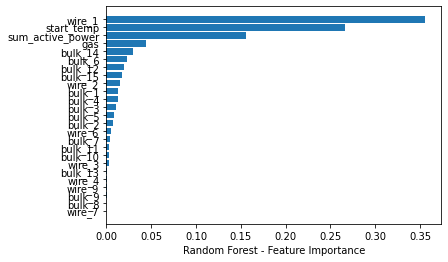

<Figure size 360x2.16e+11 with 0 Axes>

In [96]:
sorted_idx = model_RF.feature_importances_.argsort()
plt.barh(features.columns[sorted_idx], model_RF.feature_importances_[sorted_idx])
plt.xlabel("Random Forest - Feature Importance")
plt.figure(figsize=(5,3000000000))

In [86]:
%%time

model_CB = CatBoostRegressor(verbose=False)
model_CB.set_params(**best_params_CBR)
model_CB.fit(features_train, target_train)
target_predict_CB = model_CB.predict(features_test)
test_MAE_CBR = mean_absolute_error(target_predict_CB, target_test)
print('CatBoostRegressor')
print('MAE on test = ', test_MAE_CBR)

CatBoostRegressor
MAE on test =  5.234014653424193
CPU times: user 3.74 s, sys: 67.9 ms, total: 3.8 s
Wall time: 5.51 s


<Figure size 360x2.16e+11 with 0 Axes>

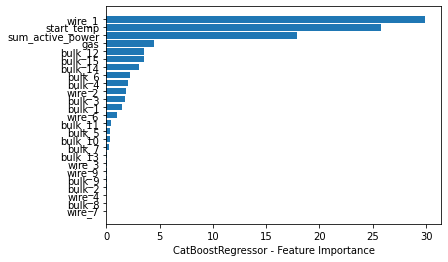

<Figure size 360x2.16e+11 with 0 Axes>

In [95]:
sorted_idx = model_CB.feature_importances_.argsort()
plt.barh(features.columns[sorted_idx], model_CB.feature_importances_[sorted_idx])
plt.xlabel("CatBoostRegressor - Feature Importance")
plt.figure(figsize=(5,3000000000))

In [90]:
%%time

model_LG = LGBMRegressor()
model_LG.set_params(**best_params_LGBMR)
model_LG.fit(features_train, target_train)
target_predict_LG = model_LG.predict(features_test)
test_MAE_LGBMR = mean_absolute_error(target_predict_LG, target_test)
print('LGBMRegressor')
print('MAE on test = ', test_MAE_LGBMR)

LGBMRegressor
MAE on test =  5.434725398583605
CPU times: user 582 ms, sys: 8.31 ms, total: 590 ms
Wall time: 564 ms


<Figure size 360x2.16e+11 with 0 Axes>

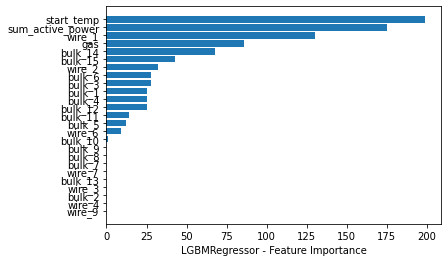

<Figure size 360x2.16e+11 with 0 Axes>

In [97]:
sorted_idx = model_LG.feature_importances_.argsort()
plt.barh(features.columns[sorted_idx], model_LG.feature_importances_[sorted_idx])
plt.xlabel("LGBMRegressor - Feature Importance")
plt.figure(figsize=(5,3000000000))

In [91]:
index = ['LinearRegression',
         'RandomForestRegressor',
         'CatBoostRegressor',
         'LGBMRegressor']
data = {'MAE на CV':[cv_MAE_LR,
                     cv_MAE_RFR,
                     cv_MAE_CBR,
                     cv_MAE_LGBMR],
        'MAE на тесте':[test_MAE_LR,
                        test_MAE_RFR,
                        test_MAE_CBR,
                        test_MAE_LGBMR]}

scores_data = pd.DataFrame(data=data, index=index)
scores_data['Выполнение минимальной задачи'] = scores_data['MAE на тесте'] <= 8.7
scores_data['Выполнение максимальной задачи'] = scores_data['MAE на тесте'] <= 6

scores_data

,MAE на CV,MAE на тесте,Выполнение минимальной задачи,Выполнение максимальной задачи
LinearRegression,7.647884,6.703948,True,False
RandomForestRegressor,6.126648,5.578707,True,True
CatBoostRegressor,5.859706,5.234015,True,True
LGBMRegressor,5.926771,5.434725,True,True


### Вывод по пункту 4

    Модели протестированны. Построены графики важности факторов по силе влияния на целевой признак. Построена итоговая таблица.
    
    Лучшей моделью по метрике MAE стала CatBoostRegressor (MAE = 5.234015 на тесте и 5.859706 на CV). Другие модели, а точнее RandomForestRegressor и LGBMRegressor подходят под условие проекта. А LinearRegression единственная модель, не выполнившая "максимальную задачу" (метрика MAE больше 6 - MAE на тесте = 6.703948)

## Итоговый вывод / отчет по решению

**В ходе работы над проектом было выполнено:**

1)Изучены данные (об электродах, о подаче сыпучих материалов (объём),  о подаче сыпучих материалов (время), о продувке сплава газом, результаты измерения температуры, о проволочных материалах (объём), о проволочных материалах (время))

    Посмотрели на таблицы и информацию о них, посмотрели уникальные значения столбцов таблицы, построили графики.
    Мы увидели, что имена столбцов нужно превести к английском языку прописными буквами и избавиться от пробелов, есть столбцы, которые могут не использовать тип float, так как хранят только целые числа.

    Также мы увидели:
        -аномальное значение реактивной мощности в таблице data_arc
        -в таблицах разное количество уникальных номеров партии key. Это может означать, что данные по партии могли быть утеряны или над ней не выполнялся технологический этап.
        -пропуски значений в столбцах (это ошибка датчика, который не передал информацию или отсутствие действия/замера на этой стадии). 
        -в таблицах data_bulk и data_wire указаны 15 и 9 столбцов о различных материалах. Это значит, что в каждую партию может идти определенный набор из них.

    Поняли,что данные требуют предобработки и группировки по признаку key и что данные об активной и реактивной мощности распределены со смещением влево, данные о температуре распределены без смещения.

2)Подготовлены данные

        -нашли суммы значений активной и реактивной мощности
        -нашли все записи по температурам, где есть минимум два значения температуры и создадим новую таблицу из первого и последнего замера
        -значения столбца key перевели в индексы датафреймов
        -заполнили nan значениями 0 для таблиц data_bulk и data_wire
        -изменили типы данных

    Составили из таблицы data_arc сгрупированную таблицу data_arc_sum по key для дальнейшего объединения данных(чем больше энергии было затрачено на нагрев, тем больше должна быть темпереатура

    Удалили из таблицы партии key, которые не подходят по следующим условиям:
        Нет финального замера. Когда температуру замеряли до окончания последней операции нагрева дугой
        Только один замер температуры.

    Получили срез со значениями времени начального и конечного замера, сформировали новый срез на основе времени и сохранили его в data_temp_final. А также преобразовали index в значения столбца key

    Так как наша цель - предсказывать значение end_temp - то мы удалили партии, где нет информации о температуре. 
    Столбец wire_5 удалили из-за отсуствия информации во всех записях. Привели типы столбцов start_temp, end_temp и bulk составляющих к целому типу (так как там храняться только целые числа). Все NaN заполнили значениями 0.

    Изучили распределения данных и выполнили оценку мультиколлинеарности и отсутсвие зависимостей между целевым признаком (столбец end_temp) и остальными: сильные прямопропоциональные зависимости между sum_active_power и sum_reactive_power и bulk_9 и wire_8. Так как они дублируют по сути друг друга, удалили из обучения sum_reactive_power и wire_8.

    Провели оценку корреляции столбцов: увидели, что не все столбцы значимо влияют на данные. Для выявления аномалий возьмем те, чья корреляция больше 10%. 
    Количество аномалий (KNN):  196

    Данные были подготовлены для обучения модели.

3)Обучены модели

    Произведен поиск гиперпараметров для получения лучшего результата:

    LinearRegression

        Среднее значение MAE =  7.647884400270078
        CPU times: user 215 ms, sys: 250 ms, total: 465 ms
        Wall time: 444 ms

    RandomForestRegressor

        Наилучшее MAE = 6.126648. Лучший набор параметров {'criterion': 'mse', 'n_estimators': 850,'random_state': 12345}

    CatBoostRegressor

        Среднее значение MAE =  5.859705871057433
        CPU times: user 16.6 s, sys: 601 ms, total: 17.2 s
        Wall time: 23.5 s

    LGBMRegressor

        Наилучший MAE = 5.926771. Лучший набор параметров {'learning_rate': 0.08, 'num_leaves': 10,'random_state': 12345}

4)Протестированны модели

    Протестировали модели для оценки их эффективности. Качественной оценкой будем считать выполнения двух условий: 1)Наихудший показатель МАЕ < 8.7 - минимальная задача; 2)Идеальный показатель МАЕ < 6. - максимальная задача.

        LinearRegression
        MAE on test =  6.703947948668354
        CPU times: user 18.8 ms, sys: 24.9 ms, total: 43.8 ms
        Wall time: 12.7 ms

        RandomForestRegressor
        MAE on test =  5.578707415927264
        CPU times: user 10.7 s, sys: 36.8 ms, total: 10.7 s
        Wall time: 11 s

        CatBoostRegressor
        MAE on test =  5.234014653424193
        CPU times: user 3.74 s, sys: 67.9 ms, total: 3.8 s
        Wall time: 5.51 s

        LGBMRegressor
        MAE on test =  5.434725398583605
        CPU times: user 582 ms, sys: 8.31 ms, total: 590 ms
        Wall time: 564 ms


    Построены графики важности факторов по силе влияния на целевой признак:
        1) Для RandomForestRegressor самые важные параметры - это wire 1, start temp, sum active power
        2) Для CatBoostRegressor самые важные параметры - это wire 1, start temp, sum active power
        3) Для LGBMRegressor  самые важные параметры - это start temp, sum active power, wire 1
    Факторы wire 3, wire 4, wire 7, wire 9, bulk 2, bulk 7, bulk 8, bulk 9, bulk 13 являются незначительными для всех трех моделей.

    Построенна итоговая таблица:
    -Лучшей моделью по метрике MAE стала CatBoostRegressor (MAE = 5.234015 на тесте и 5.859706 на CV). 
    -Другие модели, а точнее RandomForestRegressor и LGBMRegressor подходят под условие проекта. 
    -LinearRegression единственная модель, не выполнившая "максимальную задачу" (метрика MAE больше 6 - MAE на тесте = 6.703948)
    -Самой быстрой оказалась модель LGBMRegressor, а самая медленная LinearRegression.